

# Part 2. Lifetime exposure

Functions from dem4cli for:

- GMT mapping : this is done year-to-year by matching smoothed GMT timeseries of your original simulation with target stylized GMT timeseries
- Land fraction exposed / average exceedances per year: Note - If your data is binary you will get the annual fraction of land exposed, but if it is not binary you will get the area-weighted average number of exceedances
- Lifetime exposure : per region/country, birthyear and GMT stylized pathways

To do / issues:
- add example smoothing da
- add back 'raw' RCP in le and lfe output if you pick to smooth the data? 
- region_names if subnational make them a bit more helpful! latin names not the acronyms

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from dem4cli import * # to call fxns directly


In [3]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [4]:
#bbox_indiaws = [ 2.00, 35.00, 66.00, 100.00 ]
bbox_indiaws = [ 2.00, 40.00, 66.00, 100.00 ]

## 1) Shapefile preprocessing

Use shapefile provided by Paresh

In [5]:
# Load new shapefile, explore it

# Shapefile with polygons to be used in this exercise
gdf_worldadmin = gpd.read_file('/data/brussel/vo/000/bvo00012/vsc11359/data_climakid/Shapefiles/WorldAdmin_V3/WordlAdminV3.shp')

print(gdf_worldadmin.columns)
print(gdf_worldadmin[["GMI_CNTRY"]].head())


Index(['FID_world_', 'NAME', 'GMI_CNTRY', 'REGION', 'FID_IndiaB', 'OBJECTID_1',
       'AREA', 'PERIMETER', 'STNAME', 'ST_CODE', 'HDI', 'Shape_Leng',
       'Shape_Area', 'geometry'],
      dtype='object')
  GMI_CNTRY
0       AFG
1       ALB
2       DZA
3       AND
4       AGO


In [6]:
# Remove second entry for countries with double entries

# Shapefile with polygons to be used in this exercise
gdf_worldadmin = gpd.read_file('/data/brussel/vo/000/bvo00012/vsc11359/data_climakid/Shapefiles/WorldAdmin_V3/WordlAdminV3.shp')

# Drop rows where GMI_CNTRY is missing or empty 
gdf_worldadmin = gdf_worldadmin[gdf_worldadmin["GMI_CNTRY"].notna() & (gdf_worldadmin["GMI_CNTRY"] != "")].copy()

# Rename to match the column name in the original shapefile, required to be consistent with pipeline
gdf_worldadmin = gdf_worldadmin.rename(columns={"GMI_CNTRY": "ADM0_A3"})

# Remove duplicates, keep only first occurrence of each country ---
gdf_worldadmin = gdf_worldadmin.drop_duplicates(subset="ADM0_A3", keep="first").reset_index(drop=True)

modified_shapefile = "/data/brussel/vo/000/bvo00012/vsc11359/data_climakid/Shapefiles/WorldAdmin_V3/WorldAdmin_V3_woduplicates.shp"
gdf_worldadmin.to_file(modified_shapefile)
print(f"Updated shapefile written to: {modified_shapefile}")

Updated shapefile written to: /data/brussel/vo/000/bvo00012/vsc11359/data_climakid/Shapefiles/WorldAdmin_V3/WorldAdmin_V3_woduplicates.shp


## 2) Population preprocessing

See part 1 for more details: load and preprocess all demographic data (population, cohort sizes, life expectancy)

In [7]:
d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_indiaws,

    filepath_countrymask = modified_shapefile,
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask']

load_country_metadata took 0.09 s
load_unwpp_lifeexpectancy took 22.39 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 23.60 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 2.91 s
load_countrymask took 1.45 s
preprocess_all_country_data took 50.49 s


In [8]:
da_life_expectancy = (
    df_life_expectancy_5
    .to_xarray()
    .to_array('country')
    .rename({'Year': 'birth_year'})
    .astype(float)
)

In [9]:
df_life_expectancy_5

Country,Afghanistan,Bangladesh,Bhutan,China,India,Indonesia,Kyrgyzstan,Malaysia,Maldives,Myanmar,Nepal,Pakistan,Sri Lanka,Tajikistan,Thailand,Turkmenistan,Uzbekistan
Year,,,,,,,,,,,,,,,,,
1950,54.7051,64.3785,57.9877,63.3719,64.9698,64.4966,69.7542,66.4392,63.9401,62.6148,62.5044,62.6678,70.9775,70.2939,64.0547,68.1564,71.5994
1951,54.9914,64.5367,58.0507,63.7418,65.1229,64.8597,69.93,66.9031,63.8358,62.9,62.4709,63.1308,71.3957,70.4403,64.265,68.3596,71.7428
1952,55.3287,65.1587,58.1325,64.1075,65.192,65.2115,70.0851,67.3864,63.7576,63.2916,62.495,63.5415,71.7427,70.6044,64.4666,68.545,71.891
1953,55.6465,65.3259,58.2343,64.3401,65.3613,65.232,70.2454,67.9438,63.7143,63.649,62.5481,63.9462,72.1706,70.7993,64.6241,68.7415,72.0515
1954,55.9651,65.6375,58.3607,59.6083,65.6637,65.7349,70.4077,68.507,63.6957,63.8958,62.719,64.333,72.5638,71.0318,64.9301,68.9108,72.2161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,82.9225,81.2563,85.5551,80.6474,78.9437,79.1021,83.6094,88.1359,76.2366,78.775,78.0595,84.4865,79.9808,83.8029,78.91,79.8067
2022,76.441,83.1252,81.4446,85.748,80.8202,79.0574,79.211,83.7631,88.3445,76.3769,78.9434,78.1174,84.6453,80.0795,83.9901,78.9788,79.9032
2023,76.5566,83.3198,81.6378,85.9295,80.9699,79.1701,79.3258,83.9184,88.5411,76.5151,79.1097,78.1822,84.8139,80.1706,84.1884,79.0452,80.0172


## 3) Load GMT stylized trajs

Load stylized GMT trajectories to emulate with the GMT-remapping. 

Using the options : 
- extension past 2100  with 10yrtrend (also available: 10yrmean, lastyear)
- Smoothing of first decades (OS and noOS currently not smoothed). Also available: no smoothing



In [10]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

load_GMT took 8.18 s


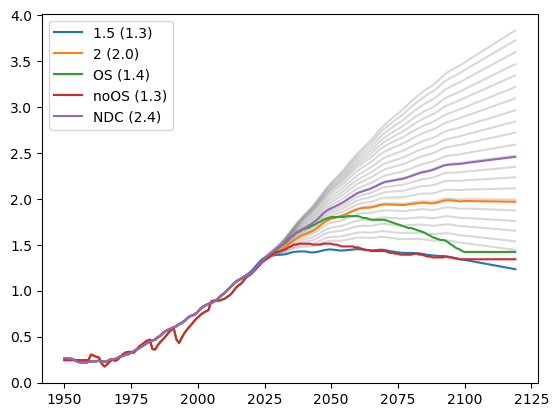

In [11]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

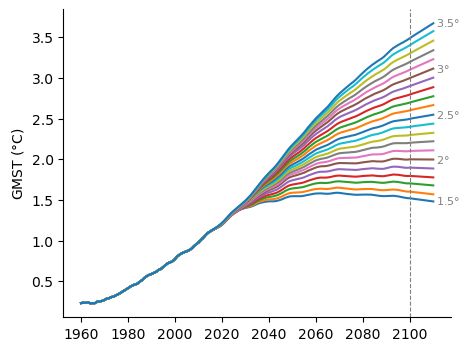

In [12]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

## 4) Load climate data and GMT-mapping recipe

Equivalent of old load_isimip() function. Loads in metadata with remapping recipe based on each target trajectory, linked to each original simulation

You can account for re-baselining GMTs to a different baseline (e.g. a bias-adjustment period)



In [13]:
# We will run the load_climate_data function with these arguments:

data_source = 'ISIMIP'
project_phase = 'ISIMIP2B'
GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS]
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
rolling_window=21
min_periods=11
max_diff_valid=.2


# One may choose among those GCMs depending on the data source:
GCMs = ['GFDL-ESM2M', 'HadGEM2-ES', 'IPSL-CM5A-LR', 'MIROC5']  # for ISIMIP 2b indicators
#GCMs = ['MPI-ESM1-2-HR'] # for ISIMIP3b indicators
#GCMs = ['CanESM5'].   # for ClimaKid indicators

# One may choose among those scenarios depending on the data source:
scenarios = ['rcp26', 'rcp60', 'rcp85'] # for ISIMIP 2b indicators
#scenarios = ['ssp370'] # for ISIMIP3b indicators

# One may choose among those indicators depending on the data source:
extremes = ["heatwavedarea"]  # for ISIMIP2b, choose among "heatwavedarea", "tropicalcyclonedarea", "floodedarea", "driedarea", "cropfailedarea", "burntarea"
#extremes = # for ISIMIP3b, choose among "heatwavedarea", "tropicalcyclonedarea", "floodedarea", "driedarea", "cropfailedarea", "burntarea"

# One may choose among those impact model names epending on the data source:
IMs = {f"{extremes[0]}": ['hwmid99']} # e.g. for ISIMIP2B indicators
# IMs = {f"{extremes[0]}": ['hwmid-humidex']}  # e.g. for ISIMIP3B

In [14]:
if project_phase.lower() == 'isimip2b':

    # This piece of code reads GMST values from GCMs used in ISIMIP2b and stores them in a dataframe saved as csv, in the format required for the rest of the code to work.

    dir_gmst_gcms = '/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/DerivedInputData/globalmeans/tas'
    simulations = ['historical', 'rcp26', 'rcp45', 'rcp60', 'rcp85']
    file_gmst_gcms = '/data/brussel/vo/000/bvo00012/vsc11359/dem4cli/data/gmst_gcms_ISIMIP2b.csv'

    # Initialize an empty DataFrame
    df_long = pd.DataFrame(columns=['year', 'experiment_id', 'source_id', 'tas'])

    for gcm in GCMs:
        for simul in simulations:
            # Get the file path
            file_path = glob.glob(os.path.join(dir_gmst_gcms, gcm, f'tas_*{gcm}_{simul}*fldmean.yearmean.txt'))[0]

            # Read the data
            df = pd.read_csv(file_path, delim_whitespace=True, comment='#', header=None, names=['year', 'tas'])

        # Filter for years up to 2100
        #df = df[df['year'] <= 2100]

            # Add columns for experiment_id and source_id
            df['experiment_id'] = simul
            df['source_id'] = gcm

            # Append to the long DataFrame
            df_long = pd.concat([df_long, df[['year', 'experiment_id', 'source_id', 'tas']]], ignore_index=True)

    # Sort the DataFrame
    df_long = df_long.sort_values(by=['year', 'experiment_id', 'source_id']).reset_index(drop=True)

    # Export the DataFrame to a CSV file
    df_long.to_csv(file_gmst_gcms, index=True)

    print(f"Data exported to {file_gmst_gcms}")

elif project_phase.lower() == 'isimip3b':
    # for Lange et al indicators from ISIMIP3b
    file_gmst_gcms = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')

    # for ClimaKid indicators
    #file_gmst_gcms = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_allmodels.csv')

Data exported to /data/brussel/vo/000/bvo00012/vsc11359/dem4cli/data/gmst_gcms_ISIMIP2b.csv


In [15]:
df_gmst = pd.read_csv(file_gmst_gcms)
print(df_gmst['experiment_id'].unique())
print(df_gmst['source_id'].unique())
#print(df_gmst['year'].unique())
df_gmst

['historical' 'rcp26' 'rcp45' 'rcp60' 'rcp85']
['GFDL-ESM2M' 'HadGEM2-ES' 'IPSL-CM5A-LR' 'MIROC5']


,Unnamed: 0,year,experiment_id,source_id,tas
0,0,1861,historical,GFDL-ESM2M,286.620
1,1,1861,historical,HadGEM2-ES,287.113
2,2,1861,historical,IPSL-CM5A-LR,286.365
3,3,1861,historical,MIROC5,286.824
4,4,1862,historical,GFDL-ESM2M,286.723
...,...,...,...,...,...
3079,3079,2299,rcp26,HadGEM2-ES,288.471
3080,3080,2299,rcp26,IPSL-CM5A-LR,288.227
3081,3081,2299,rcp26,MIROC5,288.167
3082,3082,2299,rcp45,IPSL-CM5A-LR,290.468


In [16]:
gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction

# since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this 

0.7432

In [17]:
d_climate_data_meta = load_climate_data(
    data_source = data_source,
    project_phase = project_phase,
    extremes = extremes,                   # e.g. "FWI95d"
    gcm_names = GCMs,
    impact_model_names = IMs,             
    df_GMT_strj = df_GMT_strj ,                # stylized trajectories
    scenarios = scenarios,
    GMT_extra_trajectories = GMT_extra_trajectories,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    filepath_model_gmst = file_gmst_gcms,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = gmt_anomaly_correction,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for heatwavedarea
Processing for hwmid99
load_climate_data took 1.18 s


In [18]:
print(d_climate_data_meta[1])

{'data_source': 'ISIMIP', 'project_phase': 'ISIMIP2B', 'extreme': 'heatwavedarea', 'impact_model': 'hwmid99', 'gcm': 'GFDL-ESM2M', 'scenario': 'rcp26', 'GMT':            tas
1950  0.329718
1951  0.345067
1952  0.335823
1953  0.317829
1954  0.288233
...        ...
2115  1.325800
2116  1.325800
2117  1.325800
2118  1.325800
2119  1.325800

[170 rows x 1 columns], 'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2]), 'GMT_strj_valid': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'ind_RCP2GMT_strj': array([[  6,   6,   6, ...,   6,   6,   6],
       [  7,   7,   7, ...,   7,   7,   7],
       [  7,   7,   7, ...,   7,   7,   7],
       ...,
       [129, 129, 129, ..., 129, 129, 129],
       [129, 129, 129, ..., 129, 129, 129],
       [129, 129, 129, ..., 129, 129, 129]]), 'GMT_15_maxdiff': 0.09737862612524428, 'GMT_15_valid': True, 'ind_RCP2GMT_15': array([  6,   7,   7,  24,   9,  18,  16,  16,  16,  16,  21,  17,  17,
     

In [19]:
print(d_climate_data_meta.keys())
for key, item in d_climate_data_meta.items():
    print(f"Entry {key} has keys: {list(item.keys())}")
    print(f"  GCM for {key}: {item['gcm']}")
d_climate_data_meta

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
Entry 1 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
  GCM for 1: GFDL-ESM2M
Entry 2 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
  GCM for 2: GFDL-ESM2M
Entry 3 has keys: ['data_source', 'proj

{1: {'data_source': 'ISIMIP',
  'project_phase': 'ISIMIP2B',
  'extreme': 'heatwavedarea',
  'impact_model': 'hwmid99',
  'gcm': 'GFDL-ESM2M',
  'scenario': 'rcp26',
  'GMT':            tas
  1950  0.329718
  1951  0.345067
  1952  0.335823
  1953  0.317829
  1954  0.288233
  ...        ...
  2115  1.325800
  2116  1.325800
  2117  1.325800
  2118  1.325800
  2119  1.325800
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2]),
  'GMT_strj_valid': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[  6,   6,   6, ...,   6,   6,   6],
         [  7,   7,   7, ...,   7,   7,   7],
         [  7,   7,   7, ...,   7,   7,   7],
         ...,
         [129, 129, 129, ..., 129, 129, 129],
         [129, 129, 129, ..., 129, 129, 129],
         [129, 129, 129, ..., 129, 129, 129]]),
  'GMT_15_maxdiff': 0.09737862612524428,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([  6,

In [20]:
df_mapping = pd.DataFrame(data=d_climate_data_meta[1]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
df_mapping

# what index of the simulation is mapped, for all GMT levels, to each year in the scenario-GCM combination corresponding to the first dictionary entry

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6
1951,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
1952,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
1953,24,24,24,24,24,24,24,24,24,24,...,24,24,24,24,24,24,24,24,24,24
1954,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,129,129,129,129,129,129,129,129,129,129,...,129,129,129,129,129,129,129,129,129,129
2116,129,129,129,129,129,129,129,129,129,129,...,129,129,129,129,129,129,129,129,129,129
2117,129,129,129,129,129,129,129,129,129,129,...,129,129,129,129,129,129,129,129,129,129
2118,129,129,129,129,129,129,129,129,129,129,...,129,129,129,129,129,129,129,129,129,129


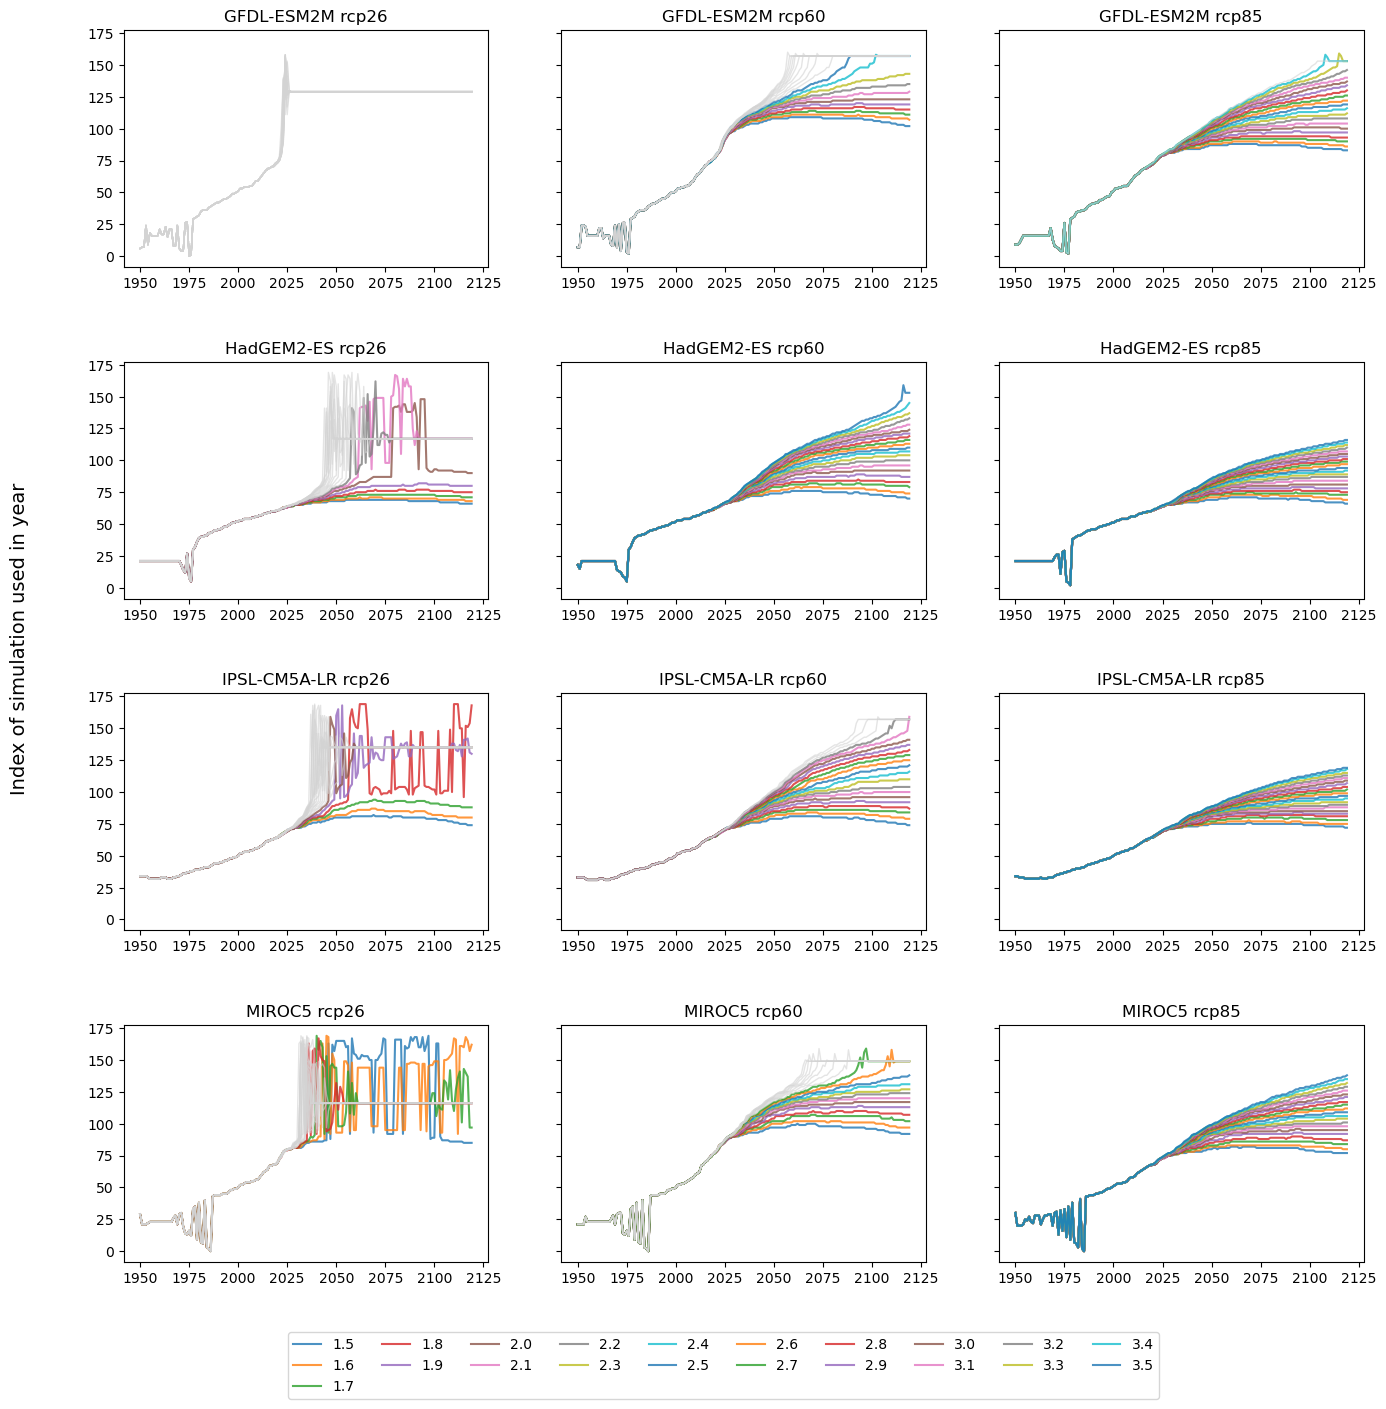

In [ ]:
# PLOTTING
# Visualise the GMT trajectories that can be reconstructed using the remapping procedure

# Exercise: 
# what is being shown on the x-axis, y-axis? Give proper titles for those
# What does each subpanel correspond to?
# What does each line correspond to? 
# Why are some grey and some coloured? Why do those panels to the right have more coloured lines and those to the left less? 
# Where do the differences between the rows come from?
# Save this plot.
# How would these results differ if we look at another extreme indicator?

fig, axes = plt.subplots(4,3,figsize=(16,16),sharey=True)
axes=axes.flatten()

# Adjust the space between rows
plt.subplots_adjust(hspace=0.4)#, wspace=0.3)

# Collect all unique GMT levels (column names) for the legend
all_gmt_levels = df_GMT_strj.columns

# Create a list of proxy artists for the legend
legend_elements = [
    Line2D([0], [0], color='C{}'.format(i % 10), lw=1.5, alpha=0.8, label=level)
    for i, level in enumerate(all_gmt_levels)
]

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['gcm']+' '+d_climate_data_meta[i]['scenario'])

# Add a common y-axis label for the entire figure
fig.text(0.06, 0.5, 'Index of simulation used in year', ha='center', va='center', rotation='vertical', fontsize=14)

# Add the legend to the entire figure (outside all subplots)
fig.legend(handles=legend_elements, loc='lower center', ncol=len(all_gmt_levels)//2, bbox_to_anchor=(0.5, 0.02))

## 4) Land fraction exposed

Note! If your data is BINARY this is land fraction exposed. 

If your data is not binary but is N OF EXCEEDANCES PER YEAR, then you will get the area-weighted average n of exceedances per spatial unit

In [22]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    gcm = d_climate_data_meta[i]['gcm']
    print(i, gcm, scenario)

# get the names / experiments of each element of the dict

# for each dict entry you have remapping recipe for each valid target trajectory 

1 GFDL-ESM2M rcp26
2 GFDL-ESM2M rcp60
3 GFDL-ESM2M rcp85
4 HadGEM2-ES rcp26
5 HadGEM2-ES rcp60
6 HadGEM2-ES rcp85
7 IPSL-CM5A-LR rcp26
8 IPSL-CM5A-LR rcp60
9 IPSL-CM5A-LR rcp85
10 MIROC5 rcp26
11 MIROC5 rcp60
12 MIROC5 rcp85


In [23]:
# EXERCISE: EXPLORE NEW DICT

#d_meta_subset = dict(list(d_climate_data_meta.items())[0:13])

# Create a new dictionary excluding entries where 'scenario' is 'rcp45'
d_meta_subset = {
    outer_key: inner_dict
    for outer_key, inner_dict in d_climate_data_meta.items()
    if inner_dict.get('scenario') != 'rcp45'
    if inner_dict.get('impact_model') != 'watergap2-2e'
    if inner_dict.get('gcm') != 'IPSL-CM5A-LR'
    if inner_dict.get('gcm') != 'MIROC5'
}

# Reindex the dictionary with sequential keys
d_meta_subset = {i + 1: inner_dict for i, inner_dict in enumerate(d_meta_subset.values())}

d_meta_subset

# test just for a subset of the simulations (faster to run)

{1: {'data_source': 'ISIMIP',
  'project_phase': 'ISIMIP2B',
  'extreme': 'heatwavedarea',
  'impact_model': 'hwmid99',
  'gcm': 'GFDL-ESM2M',
  'scenario': 'rcp26',
  'GMT':            tas
  1950  0.329718
  1951  0.345067
  1952  0.335823
  1953  0.317829
  1954  0.288233
  ...        ...
  2115  1.325800
  2116  1.325800
  2117  1.325800
  2118  1.325800
  2119  1.325800
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2]),
  'GMT_strj_valid': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[  6,   6,   6, ...,   6,   6,   6],
         [  7,   7,   7, ...,   7,   7,   7],
         [  7,   7,   7, ...,   7,   7,   7],
         ...,
         [129, 129, 129, ..., 129, 129, 129],
         [129, 129, 129, ..., 129, 129, 129],
         [129, 129, 129, ..., 129, 129, 129]]),
  'GMT_15_maxdiff': 0.09737862612524428,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([  6,

In [24]:
# EXERCISE: EXPLORE NEW DICT

for i in list(d_meta_subset.keys()):
    scenario = d_meta_subset[i]['scenario']
    gcm = d_meta_subset[i]['gcm']
    im = d_meta_subset[i]['impact_model']
    extr = d_meta_subset[i]['extreme']
    print(i, gcm, scenario, im, extr)

1 GFDL-ESM2M rcp26 hwmid99 heatwavedarea
2 GFDL-ESM2M rcp60 hwmid99 heatwavedarea
3 GFDL-ESM2M rcp85 hwmid99 heatwavedarea
4 HadGEM2-ES rcp26 hwmid99 heatwavedarea
5 HadGEM2-ES rcp60 hwmid99 heatwavedarea
6 HadGEM2-ES rcp85 hwmid99 heatwavedarea


In [25]:
ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    d_climate_data_meta, # replace with d_climate_data_meta to run all data
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_indiaws,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
    smoothing_window=21                 # window to smooth also the impact data, get only forced signal not internal variability
                                        # turn this to None for default configuration
)


# note: calling this LFE can be misleading if your data is not binary!

                         🟠 Remapping Simulation 1 of 12 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4
load_climate_data_array took 0.29 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15                

Computing land fraction exposed (LFE) for 20                

Computing land fraction exposed (LFE) for NDC               

Computing land fraction exposed (LFE) for OS                

Computing land fraction exposed (LFE) for noOS              

Computing land fraction exposed (LFE) for strj              

                         🟠 Remapping Simulation 2 of 12 🟠 

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2

In [ ]:
### EXERCISE: What does the previous function generate?

print(ds_lfe_perregion_perrun.GMT)
print(ds_lfe_perregion_perrun.region)
print(region_names)
ds_lfe_perregion_perrun

<xarray.DataArray 'GMT' (GMT: 21)>
array([1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
       2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5])
Coordinates:
  * GMT      (GMT) float64 1.5 1.6 1.7 1.8 1.9 2.0 ... 3.0 3.1 3.2 3.3 3.4 3.5
<xarray.DataArray 'region' (region: 7)>
array([0, 1, 2, 3, 4, 5, 6])
Coordinates:
  * region   (region) int64 0 1 2 3 4 5 6
['South Asia' 'East Asia & Pacific' 'Europe & Central Asia' 'Low income'
 'Lower middle income' 'Upper middle income' 'World']


<xarray.Dataset>
Dimensions:                          (run: 12, region: 7, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * region                           (region) int64 0 1 2 3 4 5 6
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 0.02353 ...
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 0.02094 ...
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 nan ... ...
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 nan ... ...
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 nan ... ...
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 0.01879 ...
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 nan...

In [ ]:
# Exercise: create this dictionary of labels

rename_dict = {
    #i: " ".join(["hadgem2-es (h-c)", "rcp60 (hc)"])
    i: f"{d_climate_data_meta[i]['gcm']} {d_climate_data_meta[i]['scenario']}"
    for i in d_climate_data_meta.keys()
}

rename_dict

{1: 'GFDL-ESM2M rcp26',
 2: 'GFDL-ESM2M rcp60',
 3: 'GFDL-ESM2M rcp85',
 4: 'HadGEM2-ES rcp26',
 5: 'HadGEM2-ES rcp60',
 6: 'HadGEM2-ES rcp85',
 7: 'IPSL-CM5A-LR rcp26',
 8: 'IPSL-CM5A-LR rcp60',
 9: 'IPSL-CM5A-LR rcp85',
 10: 'MIROC5 rcp26',
 11: 'MIROC5 rcp60',
 12: 'MIROC5 rcp85'}

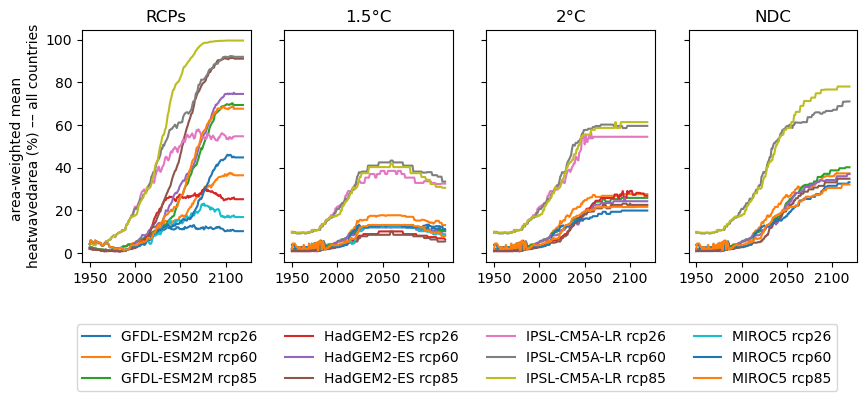

In [ ]:
# PLOTTING: projections of land fraction exposed to extreme events

# EXERCISE:
# what is being shown on the x-axis, y-axis? 
#   --> Give proper titles at least for the y-axis
# What does each subpanel correspond to?
#   --> add title for each subpanel to reflect that
# These plots are showing results for which countries or regions? 
#   --> Include this information in the y-axis title
# What does each line correspond to? 
#   --> Add a legend with labels for each line
# What do the differences between the lines tell us?
# Save this plot.
# Later in the exercise, show and save results for at least another extreme indicator.


fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_lfe_perregion_perrun*100).sel(region=6)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=6)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=6)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=6)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3], legend=False)

labels = ['RCPs', '1.5°C', '2°C',  'NDC']

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])
    ax.set_xlabel('')  # Remove the x-axis title/label for each subplot

axes[0].set_ylabel(f'area-weighted mean \n{extremes[0]} (%) –– all countries');

# Extract the lines and labels from the first subplot 
lines, line_labels = axes[0].get_legend_handles_labels()

# Add a single legend below the subplots, split into columns
fig.legend(
    lines, line_labels,
    loc='lower center',
    ncol=len(line_labels) // 3,  # Split into columns 
    bbox_to_anchor=(0.5, -0.04),  # Adjust the vertical position as needed
    fancybox=True
)

# Adjust the figure to make room for the legend
plt.subplots_adjust(bottom=0.3)

plt.show()

## 5) Lifetime exposure 

Lifetime exposure per run, and aggregated across runs ("multi-model") for original RCP and for target trajectories after remapping. 

also outputs region names and population-weighted average life-expectancy per region (should this be weighted by cohort aged 0 or total population?? - Ask Emma)



In [29]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
   d_climate_data_meta,
   df_countries, 
   countries_regions, 
   countries_mask, 
   climatedata_dir,
   da_population, 
   df_life_expectancy_5,
   da_cohort_size,
   GMT_labels=df_GMT_strj.columns , 
   GMT_extra_trajectories_names=GMT_extra_trajectories_names,
   start_birthyear=1950,
   end_birthyear=2025,
   year_start=1950,
   year_end=2119,
   bbox=bbox_indiaws,
   smoothing_window=21   
    )



                         🟠 Remapping Simulation 1 of 12 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4
load_climate_data_array took 0.22 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lif

In [30]:
# EXERCISE: what does the previous function generate?

# For each country and model run, this dataset gives the cumulated number of years a typical person from each birth cohort is or will be affected by a heatwave.

ds_le_percountry_perrun

<xarray.Dataset>
Dimensions:                    (run: 12, country: 17, birth_year: 76, GMT: 21)
Coordinates:
  * run                        (run) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * country                    (country) object 'Afghanistan' ... 'Uzbekistan'
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                        (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_percountry_perrun_RCP   (run, country, birth_year) float64 3.403 ... 4...
    le_percountry_perrun_15    (run, country, birth_year) float64 3.179 ... 5...
    le_percountry_perrun_20    (run, country, birth_year) float64 nan ... 22.88
    le_percountry_perrun_NDC   (run, country, birth_year) float64 nan ... 31.06
    le_percountry_perrun_OS    (run, country, birth_year) float64 nan ... 16.56
    le_percountry_perrun_noOS  (run, country, birth_year) float64 3.285 ... 6...
    le_percountry_perrun_strj  (run, country, birth_year, GMT) float64 nan .....

In [31]:
# EXERCISE: what does the previous function generate?

ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 12, region: 7, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * region                    (region) int64 0 1 2 3 4 5 6
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.407 ... 34.02
    le_perregion_perrun_15    (run, region, birth_year) float64 1.475 ... 13.29
    le_perregion_perrun_20    (run, region, birth_year) float64 nan ... 17.57
    le_perregion_perrun_NDC   (run, region, birth_year) float64 nan ... 19.57
    le_perregion_perrun_OS    (run, region, birth_year) float64 nan ... 16.99
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.398 ... 13.51
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 nan ... ...

In [32]:
# EXERCISE: what does the previous function generate?

region_names

array(['South Asia', 'East Asia & Pacific', 'Europe & Central Asia',
       'Low income', 'Lower middle income', 'Upper middle income',
       'World'], dtype=object)

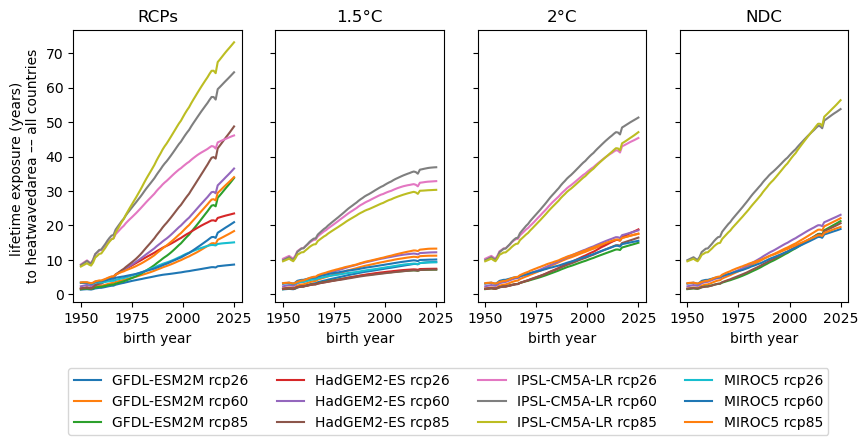

In [ ]:
# PLOTTING: projections of land fraction exposed to extreme events

# EXERCISE:
# what is being shown on the y-axis this time?
# Is it the same x-axis as before? 
#   --> Give proper axis titles 

# What does each subpanel correspond to?
#   --> add title for each subpanel to reflect that
# These plots are showing results for which countries or regions? 
#   --> Include this information in the y-axis title

# What does each line correspond to? 
#   --> Add a legend with labels for each line
# What do the differences between the lines tell us?

# Save this plot.

# Can you reproduce these results for another region (among the regions defined in this context)?
# And for a specific country?

# Later in the exercise, show and save results for at least another extreme indicator.


fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=6)['le_perregion_perrun_RCP'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[0], legend=False)
(ds_le_perregion_perrun.sel(region=6)['le_perregion_perrun_15'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[1], legend=False)
(ds_le_perregion_perrun.sel(region=6)['le_perregion_perrun_20'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[2], legend=False)
(ds_le_perregion_perrun.sel(region=6)['le_perregion_perrun_NDC'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[3], legend=False)

labels = ['RCPs', '1.5°C', '2°C',  'NDC']

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xlabel('birth year')

axes[0].set_ylabel(f'lifetime exposure (years) \nto {extremes[0]} –– all countries');

# Extract the lines and labels from the first subplot
lines, line_labels = axes[0].get_legend_handles_labels()

# Add a single legend below the subplots, split into columns
fig.legend(
    lines, line_labels,
    loc='lower center',
    ncol=len(line_labels) // 3,  # Split into 2 columns
    bbox_to_anchor=(0.5, -0.15),  # Adjust the vertical position as needed
    fancybox=True
)

# Adjust the figure to make room for the legend
plt.subplots_adjust(bottom=0.2)

plt.show()

## 6) Compute multi-model mean and model spread

Median, mean and spread across remapped / synthetic trajectories obtained from individual runs

In [ ]:
#  area-weighted average (i.e. land fraction exposed if binary)

ds_lfe_perregion_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names,
    )



Computing the MMM and stats for each region


In [35]:
# lifetime exposure 

ds_le_perregion_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [36]:

ds_lfe_percountry_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_percountry_perrun,
    GMT_extra_trajectories_names,
    )


Computing the MMM and stats for each country


In [37]:
ds_le_percountry_mmm = calc_lifetime_exposure_mmm(
    ds_le_percountry_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each country


## 7) Plot results for multi-model mean and model spread

In [38]:
region_names

# Note that World = all countries/area included in your bounding box 

array(['South Asia', 'East Asia & Pacific', 'Europe & Central Asia',
       'Low income', 'Lower middle income', 'Upper middle income',
       'World'], dtype=object)

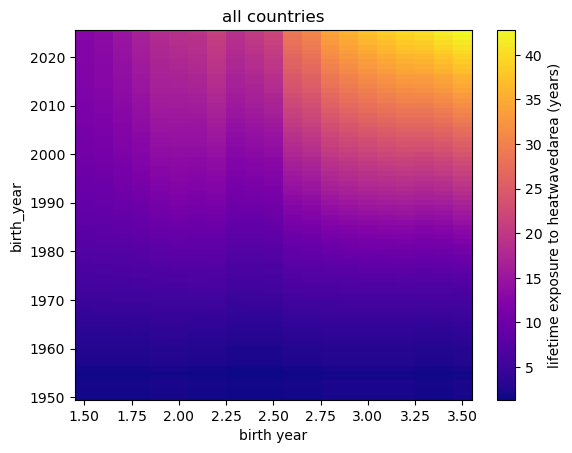

In [ ]:
# PLOTTING: lifetime exposure as a heatmap, function of birth year and GMT
# This plot displays results in a similar way as Fig. 2 in Thiery et al. (2021) or Fig.3 of Grant et al. (2025).

# EXERCISE:
# How is the heatmap constructed?
# On which model is it based?
# What are the units?
# And the axes?


plot = (ds_le_perregion_mmm['median_strj']).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes[0]} (years)"},
    cmap='plasma'
    )

# Get the current axes object
ax = plt.gca()

plt.title('all countries')

# Add a proper x-axis title
ax.set_xlabel('birth year') 

# Show the plot
plt.show()

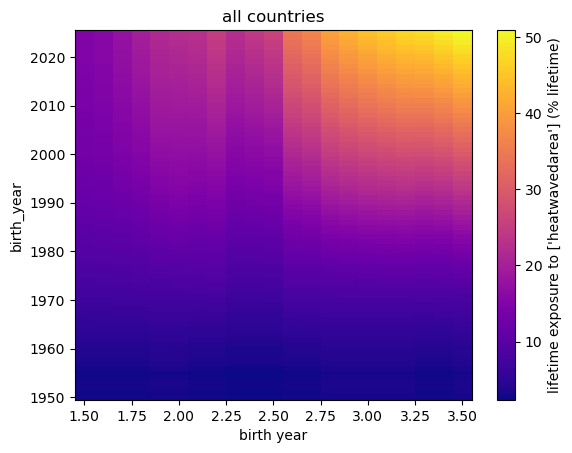

In [ ]:
# PLOTTING: lifetime exposure as a heatmap, function of birth year and GMT

# EXERCISE:
# Plot the same results, but this time express the lifetime exposure as a percentage of the lifetime.
# Hint: we're talking here about expected lifetime.

plot = (((ds_le_perregion_mmm['median_strj']) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes} (% lifetime)"},
    cmap='plasma'
    )

# Get the current axes object
ax = plt.gca()

plt.title('all countries')

# Add a proper x-axis title
ax.set_xlabel('birth year') 

plt.show()


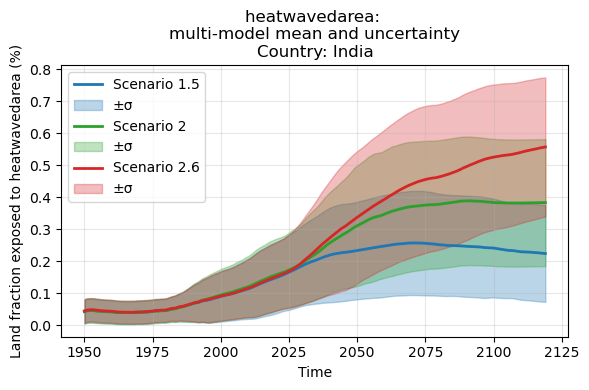

In [83]:
# PLOTTING: multi-model mean projections of land fraction exposed for various scenarios

# EXERCISE: 
# What variable is being shown here?
#   --> Add y-axis title
# What is the x-axis?
#   --> Add x-axis title
# For which region or country?
# What are the 3 scenarios we're looking at?

# Reproduce and save results for other regions, countries, scenarios of interest.
# Reproduce and save results for other indicators of interest.

# === Parameters ===
country_name = 'India'  # <-- change the country here
year_range = np.arange(1950, 1950+len(ds_lfe_percountry_mmm.time_ind))

# === Define the scenarios to plot ===
GMTs = 1.5, 2, 2.6
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}

# === Create the figure ===
plt.figure(figsize=(6,4))

for i,scen in enumerate(GMTs):
    # Extract multi-model mean and standard deviation for this scenario
    mmm = ds_lfe_percountry_mmm[f'mmm_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean() 
    std = ds_lfe_percountry_mmm[f'std_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean()
    
    # Plot the mean
    plt.plot(
        year_range, 
        mmm, 
        label=f'Scenario {scen}', 
        color=colors[i],
        lw=2
    )
    
    # Plot the uncertainty range (±2σ)
    plt.fill_between(
        year_range,
        mmm - std,
        mmm + std ,
        alpha=0.3,
        label=rf'±σ',
        color=colors[i],
        lw=1
    )

# === Customize the plot ===
plt.title(f"{extremes[0]}: \nmulti-model mean and uncertainty\nCountry: {country_name}")
plt.xlabel("Time")
plt.ylabel(f"Land fraction exposed to {extremes[0]} (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# just 2 (cold) remapped simulations, so a little jumpy in hot scenario

0.15202206630957812 16.23196352933943
1.1342184203322936 74.9923734314496
3.233188760736372 85.10579052734376


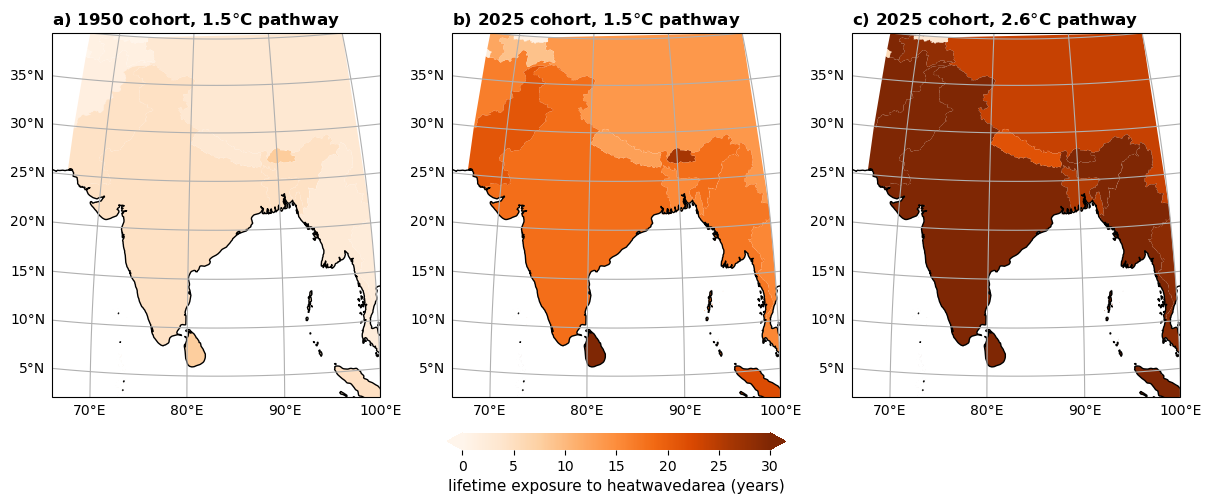

In [86]:
# PLOTTING: maps with results at the national level
# Lifetime exposure as a function of GMT level reached in 2100 and birth year
# 
# What variable should be plotted here? Let's take the example of the multi-model mean to start with.
# Write a line of code that plots results for the GMT level reached in 2100 and birth year of your choice. Each of the subpanels should show results for a different combination of GMT reached in 2100 and birth year.


# -------------------- Parameters -------------------- #
GMTs = [1.5, 1.5, 2.6]
birth_years = [1950,2025,2025]
titles = ['a)', 'b)', 'c)']

use_log_scale = False

vmin=0
vmax=30

cmap = plt.cm.Oranges # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 83, 18.5
extent = [66, 100, 2, 40]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(1,3, figsize=(12,8),subplot_kw={'projection': proj},  layout='constrained')


for ax, birth_year, GMT, title in zip(axes.flatten(), birth_years, GMTs, titles):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = ds_le_percountry_mmm[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) 

    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_country_borders.reset_index().merge(
        df_values, left_on='name', right_on='country', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    ax.set_title(title+f' {birth_year} cohort, {GMT}$\degree$C pathway', loc='left', fontweight='bold')
    ax.set_extent(extent)
    gl = ax.gridlines( draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(resolution='50m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

# colorbar 
foo = ax.collections[0]
cbar_lab = f'lifetime exposure to {extremes[0]} (years)'
cbar = fig.colorbar(foo, extend='both', ax=axes[0:3], location='bottom',shrink=0.3, fraction=0.08, pad=0.02)
cbar.set_label(label=cbar_lab,size=11)
cbar.outline.set_edgecolor('none')
